## 1. Import Libraries

In [5]:
import os
import sys
import json
import pandas as pd
import numpy as np
import lightgbm as lgb
from numerapi import NumerAPI
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import warnings
warnings.filterwarnings('ignore')

# Add repo root to path
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

from utils.metrics import calculate_metrics
from utils.visualization import display_metrics_table
from utils.model_benchmark import record_model_metrics

sns.set_style("whitegrid")
load_dotenv()

True

## 2. Initialization & Data Download

In [6]:
napi = NumerAPI(public_id=os.getenv("NAPI_PUBLIC_ID_UPLOAD"), secret_key=os.getenv("NAPI_SECRET_KEY_UPLOAD"))
DATA_VERSION = "v5.2"
DATA_DIR = "../../data"
os.makedirs(DATA_DIR, exist_ok=True)

# Download feature metadata
napi.download_dataset(f"{DATA_VERSION}/features.json", dest_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"))
feature_metadata = json.load(open(os.path.join(DATA_DIR, DATA_VERSION, "features.json")))
feature_set = feature_metadata["feature_sets"]["small"]

2026-03-08 17:58:58,113 INFO numerapi.utils: target file already exists
2026-03-08 17:58:58,113 INFO numerapi.utils: download complete


## 3. Data Loading & Pre-processing

In [7]:
print("Loading Data...")
TARGETS = ["target", "target_ender_20", "target_victor_20"]
columns_to_load = ["era"] + feature_set + TARGETS

train = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "train.parquet"), columns=columns_to_load)
validation = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), columns=["era", "target"] + feature_set)
live = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "live.parquet"), columns=["era"] + feature_set)

val_benchmarks = pd.read_parquet(os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet"))

# Apply 4-era Embargo
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 5)]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Print basic info
print(f"Training data shape: {train.shape}")
print(f"Validation data shape: {validation.shape}")
print(f"Live data shape: {live.shape}")


Loading Data...
Training data shape: (2746268, 46)
Validation data shape: (3921307, 44)
Live data shape: (7128, 43)


## 4. Target Ensembling & LightGBM Training

In [9]:
from tqdm.auto import tqdm

def train_lgbm_ensemble(train_df, val_df, live_df, features, targets):
    lgbm_params = {
        "n_estimators": 20000,
        "learning_rate": 0.01,
        "max_depth": 6,
        "num_leaves": 64,
        "colsample_bytree": 0.1,
        "subsample": 0.8,
        "objective": "regression",
        "n_jobs": -1,
        "random_state": 42,
        #"verbose": -1,
        "device_type": "gpu" # <-- Added GPU acceleration
    }
    
    val_ensemble_preds = np.zeros(len(val_df))
    live_ensemble_preds = np.zeros(len(live_df))
    
    models = []
    
    for target in tqdm(targets, desc="Training Targets"):
        # Drop NaNs for this specific target
        train_clean = train_df[features + [target]].dropna()
        
        model = lgb.LGBMRegressor(**lgbm_params)
        model.fit(train_clean[features], train_clean[target])
        models.append((target, model))
        
        # Rank predictions
        val_preds_raw = model.predict(val_df[features])
        val_ensemble_preds += pd.Series(val_preds_raw).rank(pct=True).values
        
        live_preds_raw = model.predict(live_df[features])
        live_ensemble_preds += pd.Series(live_preds_raw).rank(pct=True).values
        
    # Average the ranks and re-rank
    val_final = pd.Series(val_ensemble_preds / len(targets)).rank(pct=True).values
    live_final = pd.Series(live_ensemble_preds / len(targets)).rank(pct=True).values
    
    return val_final, live_final, models

val_predictions, live_predictions, trained_models = train_lgbm_ensemble(train, validation, live, feature_set, TARGETS)
validation["prediction"] = val_predictions
live["prediction"] = live_predictions

Training Targets: 100%|██████████| 3/3 [1:40:19<00:00, 2006.44s/it]


## 5. Feature Neutralization

In [10]:
def neutralize(df, columns, final_col, proportion=0.5):
    scores = df[final_col].values
    exposures = df[columns].values
    
    # Center
    scores = scores - scores.mean()
    exposures = exposures - exposures.mean(axis=0)
    
    # Orthogonalize
    exposure_pinv = np.linalg.pinv(exposures)
    correction = exposures.dot(exposure_pinv.dot(scores))
    neutralized_scores = scores - proportion * correction
    
    return pd.Series(neutralized_scores).rank(pct=True).values

print("Neutralizing Validation Predictions...")
validation["prediction"] = neutralize(validation, feature_set, "prediction", proportion=0.5)
print("Neutralizing Live Predictions...")
live["prediction"] = neutralize(live, feature_set, "prediction", proportion=0.5)

Neutralizing Validation Predictions...
Neutralizing Live Predictions...


## 6. Evaluation & Export

                        KEY PERFORMANCE METRICS vs GOALS                        



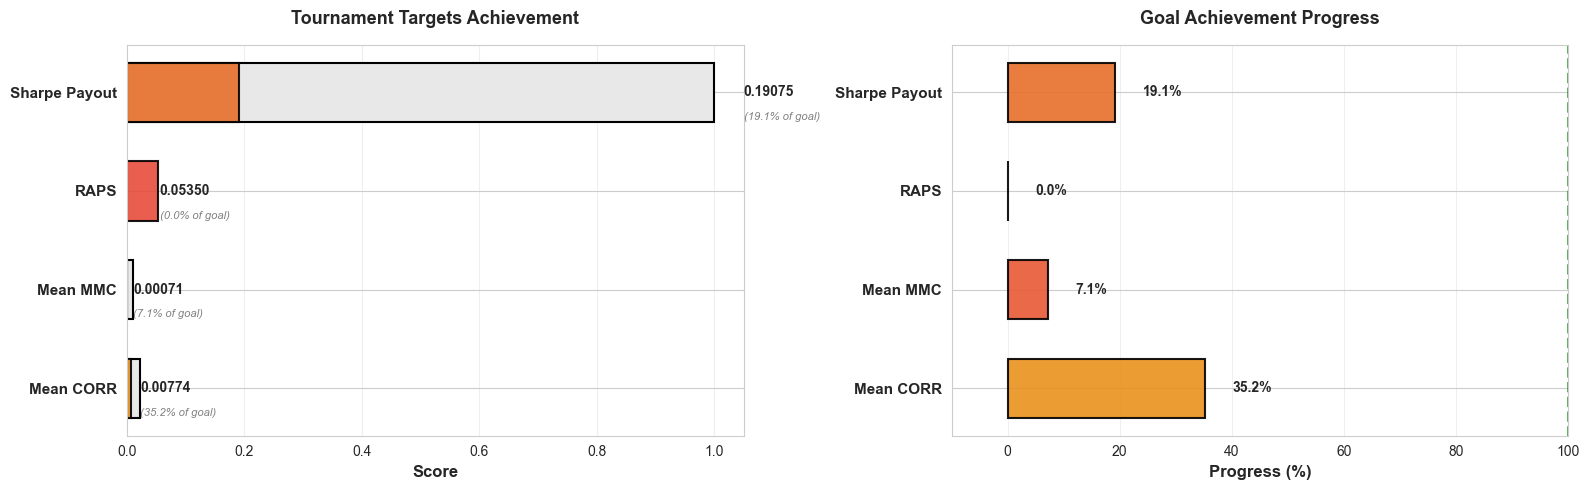

Category,Metric,Value,Goal,Status,Note
Payout,RAPS,+0.0535,+0,✅ MET,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),+0.00071,+0.01,🔴 BELOW,Uniqueness vs benchmark (2× NMR multiplier)
Payout,Mean CORR,+0.00774,+0.022,🔴 BELOW,Official Numerai correlation score (0.5× multiplier)
Risk,Sharpe Ratio,+0.5885,+1,🟠 LAGGING,Risk-adjusted return consistency
Risk,Payout Sharpe,+0.1907,+1,🔴 BELOW,Sharpe ratio of payout proxy (0.5×CORR + 2×MMC)
Risk,MMC Volatility,0.01082,—,—,Standard deviation of era-by-era MMC
Risk,Max Drawdown,-0.14864,-0.05,🟡 CLOSE,Worst sustained CORR cumulative loss
Quality,Mean FNC,+0.00610,+0,✅ MET,CORR after removing linear feature exposure
Quality,Win Rate,73.0%,+0.55,✅ MET,Fraction of eras with positive CORR
Uniqueness,P95 Max Feature Exposure,0.1408,+0.2,✅ MET,95th percentile of strongest single-feature correlation


In [ ]:
# Evaluate
metrics, per_era_df = calculate_metrics(df_validation=validation, 
                                        benchmarks=val_benchmarks,
                                        features=feature_set,
                                        target_col="target")

display_metrics_table(metrics, extended=True)

In [12]:
# Compare to benchmark models and record metrics
from pathlib import Path
from utils.model_benchmark import compare_top_models_with_current

model_name = "lgbm_ensemble_v0.3"
notebook_name = Path(globals().get("__vsc_ipynb_file__", "finance_arena_v0.3.ipynb")).stem

history_df, current_run = record_model_metrics(
    metrics=metrics,
    model_name=model_name,
    notebook_name=notebook_name,
)

leaderboard_df, is_top = compare_top_models_with_current(
    current_run_id=current_run["run_id"],
    top_n=3,
    show_message=True,
)

print("\nMODEL LEADERBOARD (Top 3 + Current)")
display_df = leaderboard_df.copy()
for col, digits in {"mean_mmc": 6, "mean_corr": 6, "raps": 4, "sharpe_payout": 4}.items():
    if col in display_df.columns:
        display_df[col] = display_df[col].astype(float).round(digits)
display(display_df)


MODEL LEADERBOARD (Top 3 + Current)


,rank,model_name,run_id,mean_mmc,mean_corr,raps,sharpe_payout,timestamp_utc,is_current
0,1,lgbm_ensemble_v0.3,52f4b2df,0.000512,0.011083,0.1332,0.2416,2026-03-07 16:38:46,True
1,2,1_hello_numerai_modified,c7fae6f9,-0.000914,0.012383,0.0774,0.1610,2026-03-01 21:40:09,False
2,3,finance_arena_v0.1,2c663abc,-0.001063,0.012799,0.0383,0.1598,2026-03-01 22:05:13,False


In [14]:
# Save Model Wrapper (for cloudpickle upload)
import cloudpickle

# The prediction function must take these two exact arguments
def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame) -> pd.DataFrame:
    # 1. Ensemble targets
    ensemble_preds = np.zeros(len(live_features))
    for target_name, model in trained_models:
        preds_raw = model.predict(live_features[feature_set])
        ensemble_preds += pd.Series(preds_raw).rank(pct=True).values
        
    final_preds = pd.Series(ensemble_preds / len(trained_models)).rank(pct=True).values
    
    # 2. Feature Neutralization (Proportion=0.5)
    scores = final_preds
    exposures = live_features[feature_set].values
    
    # Center
    scores = scores - scores.mean()
    exposures = exposures - exposures.mean(axis=0)
    
    # Orthogonalize
    exposure_pinv = np.linalg.pinv(exposures)
    correction = exposures.dot(exposure_pinv.dot(scores))
    neutralized_scores = scores - 0.5 * correction
    
    # 3. Format Submission
    submission = pd.Series(neutralized_scores, index=live_features.index).rank(pct=True, method="first")
    return submission.to_frame("prediction")

# Export to pickle
with open("finance_arena_v0_3.pkl", "wb") as f:
    cloudpickle.dump(predict, f)
print("Pipeline constructed and model exported to finance_arena_v0_3.pkl")

Pipeline constructed and model exported to finance_arena_v0_3.pkl


-----------
# Production Stage

In [ ]:
assert False

In [15]:
print("\n" + "="*80)
print("PRODUCTION STAGE: TRAINING ON ALL AVAILABLE DATA")
print("="*80 + "\n")

# 1. Concatenate the Train and Validation datasets
print("Merging train and validation datasets for final production model...")
# Ensure we only keep intersecting columns, including our TARGETS
columns_to_keep = ["era"] + feature_set + TARGETS

# WE MUST RELOAD VALIDATION: The `validation` df in memory had 4 eras stripped out via the embargo!
print("Reloading raw validation set to recover previously embargoed eras...")
full_validation = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), 
    columns=columns_to_keep
)

full_data = pd.concat([
    train[columns_to_keep], 
    full_validation[columns_to_keep]
], ignore_index=True)

print(f"Full production dataset shape: {full_data.shape}")


PRODUCTION STAGE: TRAINING ON ALL AVAILABLE DATA

Merging train and validation datasets for final production model...
Reloading raw validation set to recover previously embargoed eras...
Full production dataset shape: (6690266, 46)


In [16]:
print('>> Num of rows : ', len(full_data))
print('>> Num features : ', len(feature_set))
print('>> Num targets : ', len(TARGETS))

>> Num of rows :  6690266
>> Num features :  42
>> Num targets :  3


In [17]:
from tqdm.auto import tqdm

# 2. Define the production training function (No split, no early stopping)
def train_production_ensemble(full_df, features, targets):
    
    base_lgbm_params = {
        "n_estimators": 20000,
        "learning_rate": 0.01,
        "max_depth": 6,
        "num_leaves": 64,
        "colsample_bytree": 0.1,
        "subsample": 0.8,
        "objective": "regression",
        "n_jobs": -1,
        "random_state": 42,
        "verbose": -1,
        "device_type": "gpu" # <-- Added GPU acceleration
    }
    
    SEEDS = [42, 43, 44]
    prod_models = []
    
    for target in tqdm(targets, desc="Production Targets"):
        train_clean = full_df[features + [target]].dropna()
        
        for seed in tqdm(SEEDS, desc=f"{target} Seeds", leave=False):
            params = base_lgbm_params.copy()
            params["random_state"] = seed
            
            prod_model = lgb.LGBMRegressor(**params)
            prod_model.fit(train_clean[features], train_clean[target])
            prod_models.append((f"{target}_seed{seed}", prod_model))
            
    return prod_models

# Train the production models
prod_trained_models = train_production_ensemble(full_data, feature_set, TARGETS)
print("\n✅ Production ensemble fully trained on all available data.")

Production Targets: 100%|██████████| 3/3 [4:30:38<00:00, 5412.84s/it]  


✅ Production ensemble fully trained on all available data.


In [18]:
# 3. Save Production Model Wrapper (for cloudpickle upload)
import cloudpickle

# The prediction function must take these two exact arguments
def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame) -> pd.DataFrame:
    # 1. Ensemble targets
    ensemble_preds = np.zeros(len(live_features))
    for target_name, model in prod_trained_models: # <-- Points to the newly trained prod models
        preds_raw = model.predict(live_features[feature_set])
        ensemble_preds += pd.Series(preds_raw).rank(pct=True).values
        
    final_preds = pd.Series(ensemble_preds / len(prod_trained_models)).rank(pct=True).values
    
    # 2. Feature Neutralization (Proportion=0.5)
    scores = final_preds
    exposures = live_features[feature_set].values
    
    # Center
    scores = scores - scores.mean()
    exposures = exposures - exposures.mean(axis=0)
    
    # Orthogonalize
    exposure_pinv = np.linalg.pinv(exposures)
    correction = exposures.dot(exposure_pinv.dot(scores))
    neutralized_scores = scores - 0.5 * correction
    
    # 3. Format Submission
    submission = pd.Series(neutralized_scores, index=live_features.index).rank(pct=True, method="first")
    return submission.to_frame("prediction")

# Export to pickle
with open("finance_arena_v0_3_1.pkl", "wb") as f:
    cloudpickle.dump(predict, f)
print("\n🔥 Production Pipeline Complete. Model exported to finance_arena_v0_3_1.pkl")


🔥 Production Pipeline Complete. Model exported to finance_arena_v0_3_1.pkl
